In [1]:
import os
import scanpy as sc
import umap
import numpy as np
import warnings
import pandas as pd
import gseapy as gp

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="ChainedAssignmentError")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
BASE_PATH = r"C:\Users\mills\Desktop\Angione Lab\OC"
GRAPH_FILE = os.path.join(BASE_PATH, "adata_with_graph_embeddings.h5ad")

In [3]:
adata = sc.read_h5ad(GRAPH_FILE)
print("Graph embeddings shape:", adata.obsm['X_graph'].shape)

Graph embeddings shape: (63072, 128)


### Compute neighbors from graph embeddings

In [4]:
sc.pp.neighbors(adata, use_rep="X_graph")
sc.tl.leiden(adata, resolution=0.5)

### Compute UMAP

In [5]:
sc.tl.umap(adata)

### Plot UMAP

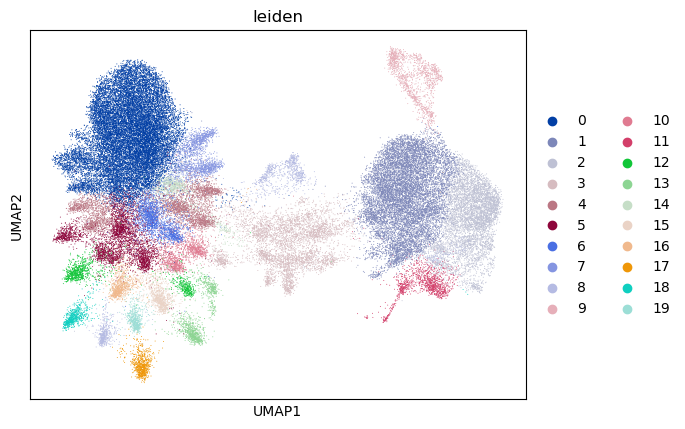

In [6]:
sc.pl.umap(adata, color="leiden")

### Find marker genes for each cluster

In [7]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

### Visualize marker genes

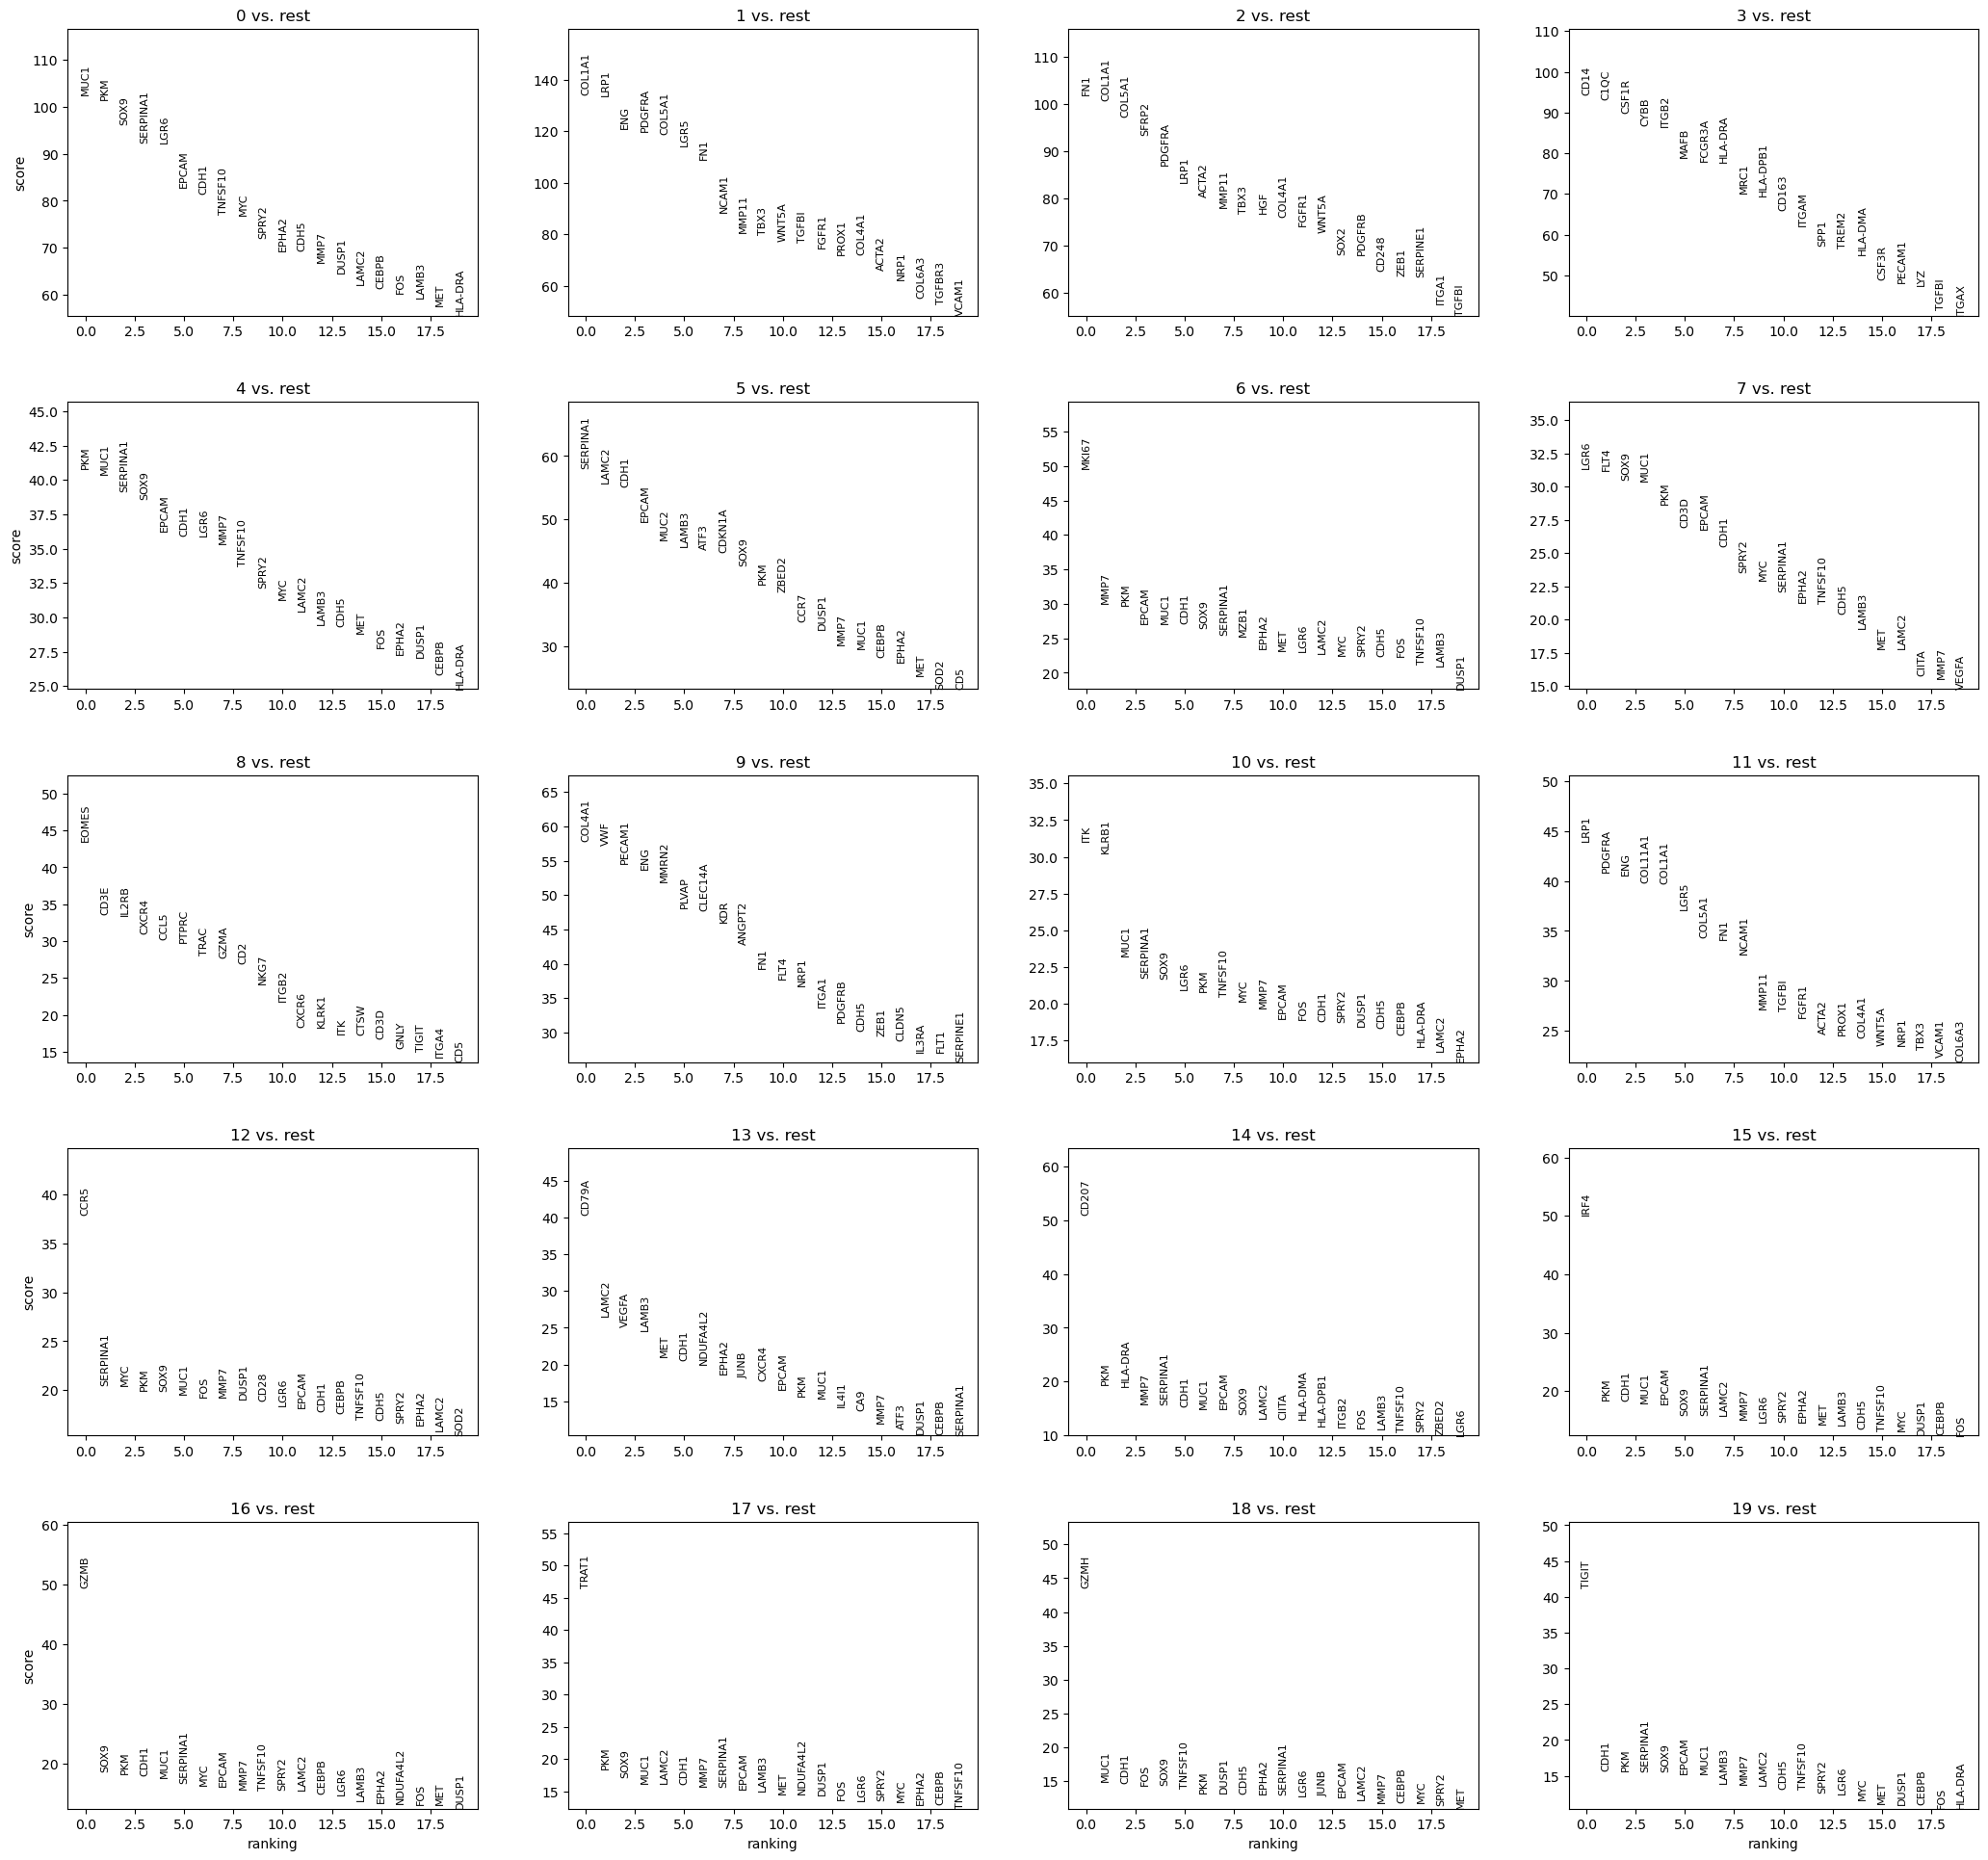

In [8]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

### Map clusters back to tissue

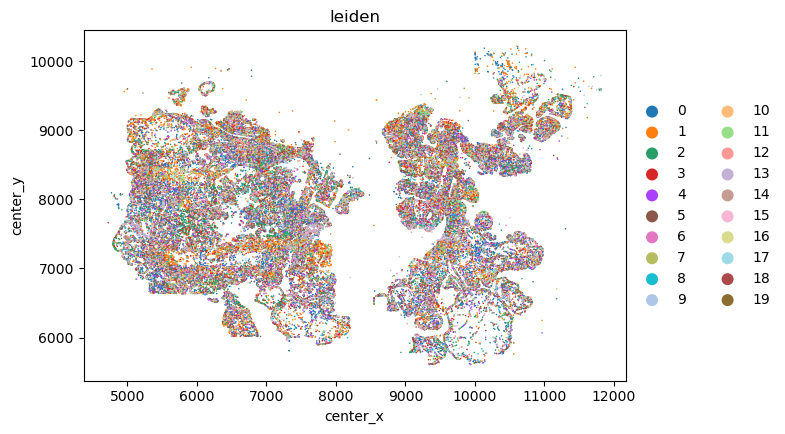

In [9]:
sc.pl.scatter(
    adata,
    x="center_x",
    y="center_y",
    color="leiden",
    size=5
)

### Compute cluster marker genes (Wilcoxon)

In [10]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    method="wilcoxon",
    pts=True   # IMPORTANT FIX
)

### Filter top genes per cluster

In [11]:
def get_filtered_genes(adata, cluster, logfc_thresh=0.25, pval_thresh=0.05, min_pct=0.05, top_n=100):
    df = sc.get.rank_genes_groups_df(adata, group=cluster)

    # Basic filtering
    if 'pct_nz_group' in df.columns:
        df_filtered = df[
            (df['pvals_adj'] < pval_thresh) &
            (df['logfoldchanges'] > logfc_thresh) &
            (df['pct_nz_group'] > min_pct)
        ]
    else:
        df_filtered = df[
            (df['pvals_adj'] < pval_thresh) &
            (df['logfoldchanges'] > logfc_thresh)
        ]

    df_filtered = df_filtered.sort_values(by='logfoldchanges', ascending=False)

    # FALLBACK: ensure enough genes
    if df_filtered.shape[0] < 10:
        df_filtered = df.sort_values(by='logfoldchanges', ascending=False).head(50)

    return df_filtered.head(top_n)

### Pathway enrichment function

In [12]:
background_genes = adata.var_names.tolist()

def run_pathway_enrichment(gene_list):
    if len(gene_list) < 5:
        return None, None
    try:
        enr_go = gp.enrichr(
            gene_list=gene_list,
            gene_sets=['GO_Biological_Process_2021'],
            organism='human',   #  corrected
            background=background_genes,
            outdir=None
        )

        enr_kegg = gp.enrichr(
            gene_list=gene_list,
            gene_sets=['KEGG_2021_Human'],
            organism='human',   #  corrected
            background=background_genes,
            outdir=None
        )

        return enr_go.results, enr_kegg.results

    except Exception as e:
        print("Enrichment error:", e)
        return None, None

### Run enrichment across all clusters

In [13]:
clusters = adata.obs['leiden'].unique().tolist()
results_summary = {}

for cl in clusters:
    print(f"\nProcessing cluster {cl}")

    df_genes = get_filtered_genes(adata, cl)
    print(f"Genes used: {df_genes.shape[0]}")

    gene_list = df_genes['names'].tolist()
    go_res, kegg_res = run_pathway_enrichment(gene_list)

    if go_res is None or kegg_res is None:
        print("Skipping enrichment (failed)")
        continue

    go_res = go_res.sort_values(['Adjusted P-value', 'Combined Score'])
    kegg_res = kegg_res.sort_values(['Adjusted P-value', 'Combined Score'])

    results_summary[cl] = {
        "genes": df_genes,
        "GO": go_res.head(5),
        "KEGG": kegg_res.head(5)
    }


Processing cluster 4
Genes used: 50

Processing cluster 2
Genes used: 50

Processing cluster 5
Genes used: 50

Processing cluster 0
Genes used: 50

Processing cluster 1
Genes used: 50

Processing cluster 3
Genes used: 50

Processing cluster 8
Genes used: 50

Processing cluster 10
Genes used: 50

Processing cluster 17
Genes used: 50

Processing cluster 7
Genes used: 50

Processing cluster 16
Genes used: 50

Processing cluster 13
Genes used: 50

Processing cluster 6
Genes used: 50

Processing cluster 15
Genes used: 50

Processing cluster 12
Genes used: 50

Processing cluster 19
Genes used: 50

Processing cluster 9
Genes used: 50

Processing cluster 11
Genes used: 50

Processing cluster 18
Genes used: 50

Processing cluster 14
Genes used: 50


### Advanced cell type interpretation

In [14]:
def interpret_cluster_advanced(genes, pathways):
    genes_str = " ".join(genes).lower()
    pathways_str = " ".join(pathways).lower()

    # Tumor epithelial
    if any(g in genes_str for g in ["epcam", "cdh1", "muc1", "sox9"]):
        if "cell cycle" in pathways_str or "proliferation" in pathways_str or any(g in genes_str for g in ["mki67", "pcna", "top2a"]):
            return "Proliferating tumor cells"
        elif "hypoxia" in pathways_str or "glycolysis" in pathways_str or "metabolic" in pathways_str:
            return "Metabolic tumor cells"
        else:
            return "Epithelial tumor cells"

    # CAFs
    elif any(g in genes_str for g in ["col1a1", "fn1", "pdgfra"]):
        return "Cancer-associated fibroblasts (CAFs)"

    # Endothelial
    elif any(g in genes_str for g in ["pecam1", "vwf", "flt4"]):
        return "Endothelial cells"

    # Immune - T/NK
    elif any(g in genes_str for g in ["cd3e", "gzmb", "gnly", "eomes"]):
        return "T/NK cells"

    # Immune - Myeloid
    elif any(g in genes_str for g in ["cd14", "csf1r", "c1qc"]):
        return "Myeloid cells"

    # Inflamed tumor microenvironment
    elif "interferon" in pathways_str or "inflammatory" in pathways_str:
        return "Inflamed tumor microenvironment"

    else:
        return "Mixed / transitional state"

### Build summary table for paper

In [15]:
final_summary = []

for cl, res in results_summary.items():
    top_genes = res["genes"]['names'].head(10).tolist()
    top_pathways = res["GO"]['Term'].head(3).tolist()

    # Use advanced interpretation
    interpretation = interpret_cluster_advanced(top_genes, top_pathways)

    final_summary.append({
        "Cluster": cl,
        "Top Genes": ", ".join(top_genes),
        "Top Pathways": ", ".join(top_pathways),
        "Interpretation": interpretation
    })

summary_df = pd.DataFrame(final_summary)

# View summary
summary_df

,Cluster,Top Genes,Top Pathways,Interpretation
0,4,"CTSG, PKM, MUC1, SERPINA1, SOX9, EPCAM, CDH1, ...",positive regulation of cell motility (GO:20001...,Epithelial tumor cells
1,2,"CTSG, FN1, COL1A1, COL5A1, SFRP2, PDGFRA, LRP1...",extracellular matrix organization (GO:0030198)...,Cancer-associated fibroblasts (CAFs)
2,5,"SERPINA1, LAMC2, CDH1, EPCAM, MUC2, LAMB3, ATF...",negative regulation of cellular macromolecule ...,Proliferating tumor cells
3,0,"MUC1, PKM, SOX9, SERPINA1, LGR6, EPCAM, CDH1, ...",positive regulation of cell motility (GO:20001...,Epithelial tumor cells
4,1,"COL1A1, LRP1, ENG, PDGFRA, COL5A1, LGR5, FN1, ...",positive regulation of cell population prolife...,Cancer-associated fibroblasts (CAFs)
5,3,"CD79A, CD14, C1QC, CSF1R, CYBB, ITGB2, MAFB, F...","inflammatory response (GO:0006954), neutrophil...",Myeloid cells
6,8,"CD79A, CTSG, EOMES, CD3E, IL2RB, CXCR4, CCL5, ...","T cell activation (GO:0042110), antigen recept...",T/NK cells
7,10,"ITK, KLRB1, MUC1, SERPINA1, SOX9, LGR6, PKM, T...",positive regulation of cell motility (GO:20001...,Epithelial tumor cells
8,17,"EOMES, TRAT1, PKM, SOX9, MUC1, LAMC2, CDH1, MM...",positive regulation of cell motility (GO:20001...,Epithelial tumor cells
9,7,"CTSG, LGR6, FLT4, SOX9, MUC1, PKM, CD3D, EPCAM...",positive regulation of macromolecule metabolic...,Proliferating tumor cells


### Map interpreted cell types unto UMAP

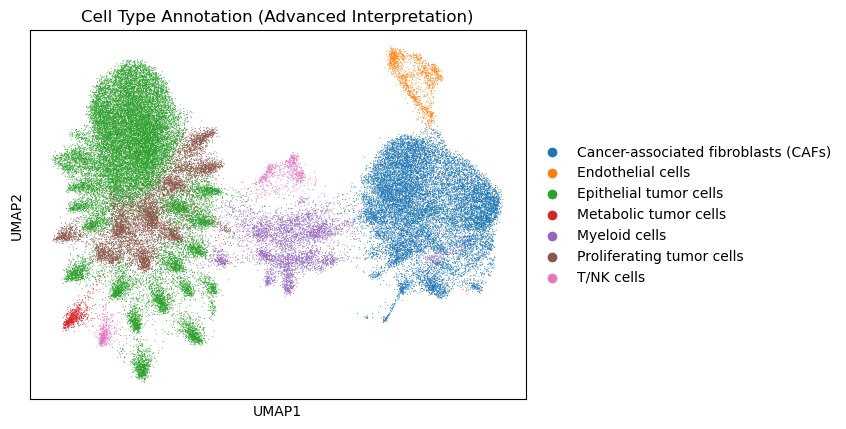

In [16]:
cluster_labels = {cl: interpret_cluster_advanced(
                    results_summary[cl]["genes"]['names'].head(10).tolist(),
                    results_summary[cl]["GO"]['Term'].head(3).tolist())
                  for cl in results_summary.keys()}

adata.obs["cell_type"] = adata.obs["leiden"].map(cluster_labels)

# Plot UMAP with interpreted cell types
sc.pl.umap(adata, color="cell_type", title="Cell Type Annotation (Advanced Interpretation)")

### Map interpreted cell types onto spatial plot

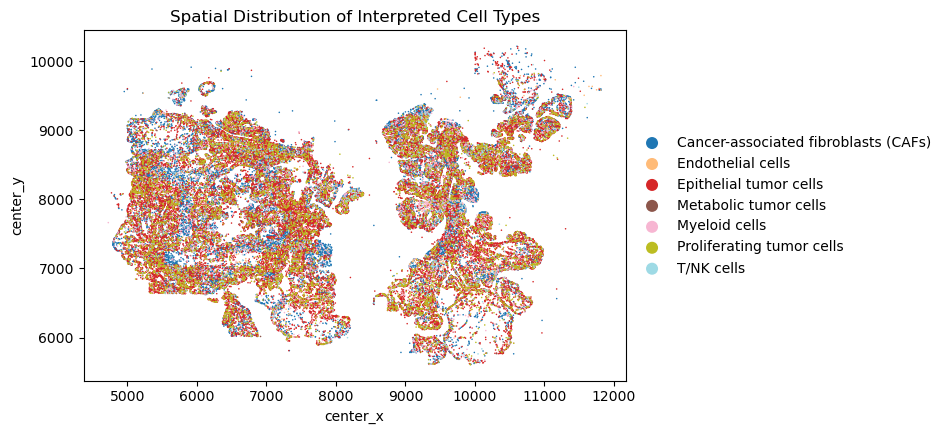

In [18]:
# 🔹 Spatial plot with interpreted cell types
sc.pl.scatter(
    adata,
    x="center_x",
    y="center_y",
    color="cell_type", 
    size=5,
    title="Spatial Distribution of Interpreted Cell Types",
    palette="tab20",   
    legend_loc='right margin'
)